<a href="https://colab.research.google.com/github/ipavlopoulos/greek-letter-vision/blob/main/cnn_embeddings_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
!gdown 1CMcTsxSzz6vzvrq_OIwOJFtowI3KHPOa
!gdown 1JnaVPaqDA60zpT7gkq6VtIPf8nlBGi87
!unzip Timeline20250531.zip

In [2]:
#@title Load Data
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from sklearn.decomposition import PCA
import numpy as np
from PIL import Image
import cv2
import pandas as pd

image_folder = 'Timeline20250531/cliplets/'
image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Function to preprocess images (resize, binariz, normalize eand flatten)
def preprocess_image(image_path, size=(64, 64)):
    # Load image and convert to grayscale
    img = Image.open(image_path).convert('L')
    img_np = np.array(img)

    # Binarization using Otsu's method
    _, img_bin = cv2.threshold(img_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Invert image: black on white background
    img_bin = 255 - img_bin

    # Resize to standard size
    img_resized = cv2.resize(img_bin, size, interpolation=cv2.INTER_AREA)

    # Normalize pixel values to [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0

    # Flatten and return
    return img_normalized.flatten()

# Preprocess all images
image_data = []
for img_file in image_files:
    try:
        processed_img = preprocess_image(img_file)
        image_data.append(processed_img)
    except Exception as e:
        print(f"Error processing image {img_file}: {e}")

image_data = np.array(image_data)

# Adding metadata
filenames = os.listdir('Timeline20250531/cliplets/')
data = pd.DataFrame({'filename': filenames})
data['letter'] = data.filename.apply(lambda x: x.split('_')[0])
data['TM'] = data.filename.apply(lambda x: int(x.split('_')[1]))
data['number'] = data.filename.apply(lambda x: x.split('_')[2].split('.')[0])

metadata = pd.read_csv('metadata.csv')

data['year'] = data.TM.apply(lambda x: metadata.loc[metadata['TM'] == x]['Year ante quem'].values[0])
data['region'] = data.TM.apply(lambda x: metadata.loc[metadata['TM'] == x]['Production Nome (supposed)'].values[0])

In [12]:
#@title Preprocess
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torchvision.transforms as transforms
import torch
import numpy as np
import cv2
import random

class RandomLacunae(object):
    """
    Apply lacunae-like erasures to simulate missing text regions (irregular blobs).
    """
    def __init__(self, num_lacunae=(1, 4), size_range=(0.02, 0.15), p=0.5, v=0.5):
        """
        Args:
            num_lacunae (tuple): min/max number of lacunae per image
            size_range (tuple): relative size range (as fraction of image area)
            p (float): probability of applying the augmentation
        """
        self.num_lacunae = num_lacunae
        self.size_range = size_range
        self.p = p
        self.v = v

    def __call__(self, img):
        if random.random() > self.p:
            return img

        img_np = np.array(img).copy()
        h, w = img_np.shape[:2]

        for _ in range(random.randint(*self.num_lacunae)):
            # Random size relative to image
            lacuna_area = random.uniform(*self.size_range) * h * w
            lacuna_w = int(np.sqrt(lacuna_area) * random.uniform(0.5, 1.5))
            lacuna_h = int(np.sqrt(lacuna_area) * random.uniform(0.5, 1.5))

            # Random center
            x = random.randint(0, w - 1)
            y = random.randint(0, h - 1)

            # Create irregular blob mask using cv2 ellipse + random contour distortion
            mask = np.zeros((h, w), dtype=np.uint8)
            cv2.ellipse(mask, (x, y), (lacuna_w//2, lacuna_h//2),
                        angle=random.randint(0, 180),
                        startAngle=0, endAngle=360,
                        color=1, thickness=-1)

            # Optionally: erode/dilate with noise to add irregularity
            if random.random() < 0.7:
                kernel_size = random.choice([3,5,7])
                kernel = np.ones((kernel_size,kernel_size), np.uint8)
                if random.random() < 0.5:
                    mask = cv2.erode(mask, kernel, iterations=1)
                else:
                    mask = cv2.dilate(mask, kernel, iterations=1)

            # Apply lacuna (set pixels to background = white/255)
            img_np[mask == 1] = 255 * self.v  # assuming grayscale / white parchment

        return torch.tensor(img_np) if isinstance(img, torch.Tensor) else img_np


# Preprocess images for 2D CNN (resize and normalize, no flattening yet)
def preprocess_image_2d(image_path, size=(64, 64)):
    img = Image.open(image_path).convert('L') # Grayscale
    img_np = np.array(img)

    # Binarization using Otsu's method
    _, img_bin = cv2.threshold(img_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Invert image: black on white background
    img_bin = 255 - img_bin

    # Resize to standard size
    img_resized = cv2.resize(img_bin, size, interpolation=cv2.INTER_AREA)

    # Normalize pixel values to [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0

    return img_normalized # Return as 2D numpy array

# Preprocess all images for 2D CNN
image_data_2d = []

for img_file in image_files:
    try:
        processed_img_2d = preprocess_image_2d(img_file)
        image_data_2d.append(processed_img_2d)
    except Exception as e:
        print(f"Error processing image {img_file} for 2D CNN: {e}")

image_data_2d = np.array(image_data_2d)

# The original image data (image_data_2d) for the 2D CNN
train_data_split = data[data['letter'] != 'Unknown'].copy()
unk_data_split = data[data['letter'] == 'Unknown'].copy()

# Get the indices for splitting
train_indices_2d = train_data_split.index.tolist()
unk_indices_2d = unk_data_split.index.tolist()

# Encode the letter labels into integers
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(train_data_split['letter'])

# Split the indices for train/val/test
train_indices_2d, test_indices_2d, y_train_encoded_2d, y_test_encoded_2d = train_test_split(
    train_indices_2d,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_indices_2d, val_indices_2d, y_train_encoded_2d, y_val_encoded_2d = train_test_split(
    train_indices_2d,
    y_train_encoded_2d,
    test_size=0.1,
    random_state=42,
    stratify=y_train_encoded_2d
)


# Select image data and labels using the indices
X_train_2d = image_data_2d[train_indices_2d]
y_train_2d = y_train_encoded_2d

X_val_2d = image_data_2d[val_indices_2d]
y_val_2d = y_val_encoded_2d

X_test_2d = image_data_2d[test_indices_2d]
y_test_2d = y_test_encoded_2d

X_unk_2d = image_data_2d[unk_indices_2d]

# --- Data Augmentation for 2D Images ---
# Define image transformations including data augmentation
data_transform = transforms.Compose([
    transforms.RandomRotation(10),      # Rotate by up to 10 degrees
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Translate horizontally and vertically
    transforms.RandomResizedCrop(size=(64, 64), scale=(0.8, 1.0)), # Random crop and resize
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Adjust brightness and contrast
    RandomLacunae(num_lacunae=(0,3), size_range=(0.02,0.15), p=0.7, v=0),
    transforms.ToTensor(),             # Convert to PyTorch Tensor (adds channel dimension)
    #transforms.RandomErasing(p=0.5, value=0), # erase parts (lacunae)
    transforms.Normalize((0.5,), (0.5,)), # Normalize (assuming grayscale images)
])

# Transformation for validation and test sets (no augmentation)
test_transform = transforms.Compose([
    # Removed redundant transforms.ToPILImage()
    transforms.ToTensor(), # Adds channel dimension
    transforms.Normalize((0.5,), (0.5,))
])

# Create custom PyTorch dataset for 2D data with augmentation
class ImageDatasetAugmented(Dataset):
    def __init__(self, X, y=None, transform=None):
        self.X = X # Expecting numpy array of images
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        # Convert numpy array (H, W) to PIL Image (H, W) expected by transforms
        # Convert back to uint8 for PIL, as transforms expect uint8 or float in [0, 1]
        # Also ensure it's in the correct mode ('L' for grayscale)
        image = Image.fromarray((image * 255).astype(np.uint8))

        if self.transform:
            # Apply the transforms
            image = self.transform(image)

        # The transform pipeline includes ToTensor() and normalization, so 'image' is now a tensor
        if self.y is not None:
            return image, self.y[idx]
        else:
            return image


batch_size = 16
train_loader_2d_aug = DataLoader(ImageDatasetAugmented(X_train_2d, y_train_2d, transform=data_transform), batch_size=batch_size, shuffle=True)
val_loader_2d = DataLoader(ImageDatasetAugmented(X_val_2d, y_val_2d, transform=test_transform), batch_size=batch_size)
test_loader_2d = DataLoader(ImageDatasetAugmented(X_test_2d, y_test_2d, transform=test_transform), batch_size=batch_size)
unk_loader_2d = DataLoader(ImageDatasetAugmented(X_unk_2d, transform=test_transform), batch_size=batch_size) # Assuming unknown inference needs standard processing

In [7]:
#@title Source (algorithm)
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torch.optim as optim
import cv2
import numpy as np
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F

class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss as in Khosla et al. (2020)
    https://arxiv.org/abs/2004.11362
    """
    def __init__(self, temperature=0.07):
        super(SupConLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        """
        features: tensor of shape [batch_size, embed_dim]
        labels: tensor of shape [batch_size]
        """
        device = features.device
        features = F.normalize(features, dim=1)

        batch_size = features.shape[0]

        # Compute similarity matrix
        similarity_matrix = torch.matmul(features, features.T) / self.temperature

        # Mask: remove self-comparisons
        mask = torch.eye(batch_size, dtype=torch.bool).to(device)
        similarity_matrix = similarity_matrix.masked_fill(mask, -1e9)

        # Positive mask: same label
        labels = labels.contiguous().view(-1, 1)
        positive_mask = torch.eq(labels, labels.T).to(device)

        # For each sample, compute log-softmax
        log_prob = F.log_softmax(similarity_matrix, dim=1)

        # Only keep positives
        mean_log_prob_pos = (positive_mask * log_prob).sum(1) / positive_mask.sum(1).clamp(min=1)

        # Final loss
        loss = -mean_log_prob_pos.mean()
        return loss

class CNN2D(nn.Module):
    def __init__(self, num_classes, image_size=(64, 64)):
        super(CNN2D, self).__init__()
        self.image_size = image_size
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        # Calculate the size of the flattened features after conv and pooling
        with torch.no_grad():
            dummy_input = torch.randn(1, 1, image_size[0], image_size[1]) # (batch_size, channels, height, width)
            dummy_output = self.pool3(self.relu(self.conv3(self.pool2(self.relu(self.conv2(self.pool1(self.relu(self.conv1(dummy_input)))))))))
            flattened_size = dummy_output.shape[1] * dummy_output.shape[2] * dummy_output.shape[3]

        self.fc1 = nn.Linear(flattened_size, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Remove the unsqueeze(1) call as ToTensor() already adds the channel dimension
        # x = x.unsqueeze(1) # Add a channel dimension (batch_size, 1, height, width)
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1) # Flatten the tensor
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

    def get_embeddings(self, x):
        """Return embeddings before the final classification layer"""
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return x   # <-- embeddings (size = 512)

class SimilarityWeightedSupConLoss(nn.Module):
    """Supervised Contrastive Loss with class-similarity-weighted negatives."""
    def __init__(self, S_class, temperature=0.07, lambda_weight=1.0, eps=1e-8):
        super().__init__()
        self.register_buffer("S_class", S_class.float())
        self.temperature = temperature
        self.lambda_weight = lambda_weight
        self.eps = eps
        C = S_class.shape[0]
        mask_offdiag = (~torch.eye(C, dtype=torch.bool, device=S_class.device))
        self.S_bar = S_class[mask_offdiag].mean().clamp(min=eps)

    def forward(self, features, labels):
        z = F.normalize(features, dim=1)
        sim = torch.matmul(z, z.t()) / self.temperature
        B = z.size(0)
        eye = torch.eye(B, device=features.device, dtype=torch.bool)
        sim = sim.masked_fill(eye, -1e9)
        y = labels.view(-1, 1)
        pos_mask = (y == y.t()) & (~eye)
        S_pairs = self.S_class[labels][:, labels]
        w = 1.0 + self.lambda_weight * (S_pairs / self.S_bar)
        neg_mask = (~pos_mask) & (~eye)
        w = w * neg_mask.float() + pos_mask.float() + eye.float()
        exp_sim = torch.exp(sim) * (1.0 - eye.float())
        denom = (w * exp_sim).sum(dim=1, keepdim=True).clamp(min=self.eps)
        log_prob = sim - torch.log(denom)
        pos_count = pos_mask.sum(dim=1).clamp(min=1)
        mean_log_prob_pos = (pos_mask.float() * log_prob).sum(dim=1) / pos_count
        loss = -mean_log_prob_pos.mean()
        return loss

def compute_prototypes(embeddings, labels, num_classes):
    protos = []
    for c in range(num_classes):
        v = embeddings[labels == c].mean(axis=0)
        v = v / (np.linalg.norm(v) + 1e-12)
        protos.append(v)
    return np.stack(protos)  # [C, D]

def build_S_from_prototypes(model, loader, device, num_classes):
    model.eval()
    Z, Y = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            z = model.get_embeddings(x).cpu().numpy()
            Z.append(z); Y.append(y.numpy())
    Z = np.vstack(Z); Y = np.concatenate(Y)
    P = compute_prototypes(Z, Y, num_classes)           # [C, D]
    # cosine similarity in [−1, 1] → clamp to [0,1]
    S = P @ P.T
    S = np.clip(S, 0.0, 1.0)
    np.fill_diagonal(S, 0.0)
    return torch.tensor(S, dtype=torch.float32, device=device)


def get_tta_embeddings(model, x, y, n_views, tta_transform, device):
    """Apply TTA safely to a batch."""
    B = x.size(0)
    x_aug_list = []
    for img in x:  # iterate over batch
        aug_imgs = [tta_transform(img.cpu()) for _ in range(n_views)]
        x_aug_list.extend(aug_imgs)
    x_aug = torch.stack(x_aug_list).to(device)
    y_aug = y.repeat(n_views)
    emb = model.get_embeddings(x_aug)
    return emb, y_aug

def train_cnn2d(model, train_loader, val_loader, device,
                num_classes, num_epochs=100, lam_scl_weight=0.1,
                n_views=2, tta_transform=None, use_swscl=True,
                use_tta=True, update_S_every=3, patience=10,
                save_path='best_cnn_letter_model.pth',
                learning_rate=0.001,
                similarity_matrix_fn=None,
                ema_alpha=0.0):
    """
    Train CNN2D with optional SW-SCL and TTA embeddings.
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    ce_loss_fn = nn.CrossEntropyLoss()
    best_val_loss = float('inf')
    epochs_no_improve = 0
    train_losses, val_losses, val_accuracies = [], [], []

    if similarity_matrix_fn is None:
        similarity_matrix_fn = build_S_from_prototypes

    S_matrix = None
    swscl_loss_fn = None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        # --- Update similarity matrix dynamically ---
        if use_swscl and (epoch % update_S_every == 0 or S_matrix is None):
            new_S = similarity_matrix_fn(model, train_loader, device, num_classes)
            if S_matrix is None or ema_alpha == 0.0:
                S_matrix = new_S
            else:
                S_matrix = ema_alpha * S_matrix + (1 - ema_alpha) * new_S
            swscl_loss_fn = SimilarityWeightedSupConLoss(S_matrix, temperature=0.07, lambda_weight=1.0)

        for x_orig, y in train_loader:
            x_orig, y = x_orig.to(device), y.to(device)

            # --- CE Loss ---
            logits = model(x_orig)
            ce_loss = ce_loss_fn(logits, y)

            # --- SW-SCL Loss ---
            if use_swscl:
                if use_tta and tta_transform is not None and n_views > 1:
                    emb, y_aug = get_tta_embeddings(model, x_orig, y, n_views, tta_transform, device)
                else:
                    emb, y_aug = model.get_embeddings(x_orig), y
                swscl_loss = swscl_loss_fn(emb, y_aug)
            else:
                swscl_loss = 0.0

            loss = ce_loss + lam_scl_weight * swscl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x_orig.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = ce_loss_fn(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        val_accuracy = correct / total
        val_losses.append(epoch_val_loss)
        val_accuracies.append(val_accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}] '
              f'Train Loss: {epoch_loss:.4f}, '
              f'Val Loss: {epoch_val_loss:.4f}, '
              f'Val Accuracy: {val_accuracy:.4f}')

        # --- Early stopping ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping triggered after {epoch+1} epochs.')
                break

    return train_losses, val_losses, val_accuracies

def evaluate(model, test_loader, device, label_encoder):
    model.eval()
    correct = 0
    total = 0
    pred, gold = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            pred.extend(predicted.cpu().numpy())
            gold.extend(labels.cpu().numpy())

    # Inverse transform the encoded predicted and true labels to get original letter names
    pred = label_encoder.inverse_transform(pred)
    gold = label_encoder.inverse_transform(gold)

    # Display classification report
    print(classification_report(gold, pred, zero_division=0))

    # Display confusion matrix
    cm_2d = confusion_matrix(gold, pred, labels=label_encoder.classes_)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_2d, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.savefig('cnn2d_aug_confusion_matrix.pdf', dpi=300, format='PDF')
    plt.show()

def custom_similarity_matrix(model, loader, device, num_classes):
    # e.g., compute S differently or add class-specific weighting
    S = build_S_from_prototypes(model, loader, device, num_classes)
    return S * 0.5  # example: scale similarity

In [13]:
model = CNN2D(num_classes=len(label_encoder.classes_), image_size=(64, 64))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.load_state_dict(torch.load('best_cnn_model.pth', map_location=torch.device(device)))

def extract_embeddings(model, dataloader, device):
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, (list, tuple)):
                images, targets = batch
                labels.extend(targets.numpy())
            else:
                images = batch
                targets = None

            images = images.to(device)
            emb = model.get_embeddings(images)  # (batch_size, 512)
            embeddings.append(emb.cpu().numpy())

    embeddings = np.vstack(embeddings)
    if labels:
        labels = np.array(labels)
        return embeddings, labels
    else:
        return embeddings

# Extract embeddings
train_embeddings, train_labels = extract_embeddings(model, train_loader_2d_aug, device)
test_embeddings, test_labels = extract_embeddings(model, test_loader_2d, device)

In [23]:
#@title KMeans on CNN embeddings
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
import numpy as np

# 1. Get train and test embeddings
train_embeddings, train_labels = extract_embeddings(model, train_loader_2d_aug, device)
test_embeddings, test_labels = extract_embeddings(model, test_loader_2d, device)

num_classes = len(np.unique(train_labels))

# 2. Run KMeans (unsupervised)
kmeans = KMeans(n_clusters=num_classes, random_state=42, n_init=20)
kmeans.fit(train_embeddings)

# 3. Assign each cluster a majority-vote label
from scipy.stats import mode

cluster_labels = {}
for c in range(num_classes):
    indices = np.where(kmeans.labels_ == c)[0]
    if len(indices) > 0:
        majority_label = mode(train_labels[indices], keepdims=False).mode
        cluster_labels[c] = majority_label

# 4. Predict test set
test_clusters = kmeans.predict(test_embeddings)
y_pred_kmeans = np.array([cluster_labels[c] for c in test_clusters])

# 5. Evaluate
print(f"KMeans-based classifier accuracy: {accuracy_score(test_labels, y_pred_kmeans)}")
print(classification_report(test_labels, y_pred_kmeans, target_names=label_encoder.classes_, zero_division=0))
#print(f"Average Silhouette Score: {silhouette_score(image_data, y_pred_kmeans)}")
print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(test_labels, y_pred_kmeans)}")
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(test_labels, y_pred_kmeans)}")
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
print(f"Homogeneity: {homogeneity_score(test_labels, y_pred_kmeans)}")
print(f"Completeness: {completeness_score(test_labels, y_pred_kmeans)}")
print(f"V-measure: {v_measure_score(test_labels, y_pred_kmeans)}")

KMeans-based classifier accuracy: 0.5827890895121014
              precision    recall  f1-score   support

       Alpha       0.17      0.46      0.25       139
        Beta       0.00      0.00      0.00        67
         Chi       0.81      0.67      0.74        85
       Delta       0.51      0.80      0.62       113
     Epsilon       0.60      0.57      0.58       138
         Eta       0.44      0.31      0.37       124
       Gamma       0.65      0.75      0.70       105
        Iota       0.48      0.55      0.51       141
       Kappa       0.82      0.81      0.81       127
      Lambda       0.53      0.50      0.52       117
          Mu       0.90      0.63      0.74       126
          Nu       0.80      0.59      0.68       134
       Omega       0.89      0.65      0.75       126
     Omicron       0.70      0.57      0.63       136
         Phi       0.69      0.95      0.80        83
          Pi       0.62      0.61      0.61       127
         Psi       0.00     

In [24]:
#@title KMeans on CNN embeddings (before augmentation)
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import numpy as np

# Reuse the extract_embeddings function from the previous cell
# Assuming image_data_2d is the preprocessed data before augmentation
# and train_indices_2d, test_indices_2d are the indices for train and test sets

# 1. Get train and test embeddings from image_data_2d
# Create dummy datasets and dataloaders for extraction without augmentation
class SimpleDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        # Convert numpy array (H, W) to PIL Image (H, W) expected by transforms
        # Convert back to uint8 for PIL, as transforms expect uint8 or float in [0, 1]
        # Also ensure it's in the correct mode ('L' for grayscale)
        image = Image.fromarray((image * 255).astype(np.uint8))

        # Apply only the test_transform (ToTensor and Normalize)
        if test_transform:
             image = test_transform(image)

        if self.y is not None:
            return image, self.y[idx]
        else:
            return image

train_dataset_no_aug = SimpleDataset(image_data_2d[train_indices_2d], y_train_encoded_2d)
test_dataset_no_aug = SimpleDataset(image_data_2d[test_indices_2d], y_test_encoded_2d)

train_loader_no_aug = DataLoader(train_dataset_no_aug, batch_size=batch_size)
test_loader_no_aug = DataLoader(test_dataset_no_aug, batch_size=batch_size)


train_embeddings_no_aug, train_labels_no_aug = extract_embeddings(model, train_loader_no_aug, device)
test_embeddings_no_aug, test_labels_no_aug = extract_embeddings(model, test_loader_no_aug, device)


num_classes = len(np.unique(train_labels_no_aug))

# 2. Run KMeans (unsupervised) on embeddings without augmentation
kmeans_no_aug = KMeans(n_clusters=num_classes, random_state=42, n_init=20)
kmeans_no_aug.fit(train_embeddings_no_aug)

# 3. Assign each cluster a majority-vote label
from scipy.stats import mode

cluster_labels_no_aug = {}
for c in range(num_classes):
    indices = np.where(kmeans_no_aug.labels_ == c)[0]
    if len(indices) > 0:
        majority_label = mode(train_labels_no_aug[indices], keepdims=False).mode
        cluster_labels_no_aug[c] = majority_label

# 4. Predict test set
test_clusters_no_aug = kmeans_no_aug.predict(test_embeddings_no_aug)
y_pred_kmeans_no_aug = np.array([cluster_labels_no_aug[c] for c in test_clusters_no_aug])

# 5. Evaluate
print("Evaluation on CNN embeddings (before augmentation):")
print(f"KMeans-based classifier accuracy: {accuracy_score(test_labels_no_aug, y_pred_kmeans_no_aug)}")
print(classification_report(test_labels_no_aug, y_pred_kmeans_no_aug, target_names=label_encoder.classes_, zero_division=0))
print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(test_labels_no_aug, y_pred_kmeans_no_aug)}")
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(test_labels_no_aug, y_pred_kmeans_no_aug)}")
print(f"Homogeneity: {homogeneity_score(test_labels_no_aug, y_pred_kmeans_no_aug)}")
print(f"Completeness: {completeness_score(test_labels_no_aug, y_pred_kmeans_no_aug)}")
print(f"V-measure: {v_measure_score(test_labels_no_aug, y_pred_kmeans_no_aug)}")

Evaluation on CNN embeddings (before augmentation):
KMeans-based classifier accuracy: 0.641567422205148
              precision    recall  f1-score   support

       Alpha       0.13      0.50      0.21       139
        Beta       0.86      0.75      0.80        67
         Chi       0.95      0.68      0.79        85
       Delta       0.88      0.58      0.70       113
     Epsilon       0.82      0.60      0.69       138
         Eta       0.78      0.61      0.68       124
       Gamma       0.63      0.79      0.70       105
        Iota       0.72      0.66      0.69       141
       Kappa       0.85      0.79      0.82       127
      Lambda       0.52      0.52      0.52       117
          Mu       0.95      0.61      0.74       126
          Nu       0.84      0.59      0.69       134
       Omega       0.88      0.60      0.71       126
     Omicron       0.66      0.64      0.65       136
         Phi       0.75      0.88      0.81        83
          Pi       0.84      0.

In [25]:
#@title KMeans on flattened pixel features
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import numpy as np

# Assuming image_data contains the flattened preprocessed images
# Assuming train_indices_2d and test_indices_2d are the indices for train and test sets
# Assuming y_train_encoded_2d and y_test_encoded_2d are the corresponding labels

# 1. Get train and test flattened pixel data
train_pixel_data = image_data[train_indices_2d]
test_pixel_data = image_data[test_indices_2d]

train_labels_pixel = y_train_encoded_2d
test_labels_pixel = y_test_encoded_2d

num_classes = len(np.unique(train_labels_pixel))

# 2. Run KMeans (unsupervised) on flattened pixel data
kmeans_pixel = KMeans(n_clusters=num_classes, random_state=42, n_init=20)
kmeans_pixel.fit(train_pixel_data)

# 3. Assign each cluster a majority-vote label
from scipy.stats import mode

cluster_labels_pixel = {}
for c in range(num_classes):
    indices = np.where(kmeans_pixel.labels_ == c)[0]
    if len(indices) > 0:
        majority_label = mode(train_labels_pixel[indices], keepdims=False).mode
        cluster_labels_pixel[c] = majority_label

# 4. Predict test set
test_clusters_pixel = kmeans_pixel.predict(test_pixel_data)
y_pred_kmeans_pixel = np.array([cluster_labels_pixel[c] for c in test_clusters_pixel])

# 5. Evaluate
print("Evaluation on flattened pixel features:")
print(f"KMeans-based classifier accuracy: {accuracy_score(test_labels_pixel, y_pred_kmeans_pixel)}")
print(classification_report(test_labels_pixel, y_pred_kmeans_pixel, target_names=label_encoder.classes_, zero_division=0))
print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(test_labels_pixel, y_pred_kmeans_pixel)}")
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(test_labels_pixel, y_pred_kmeans_pixel)}")
print(f"Homogeneity: {homogeneity_score(test_labels_pixel, y_pred_kmeans_pixel)}")
print(f"Completeness: {completeness_score(test_labels_pixel, y_pred_kmeans_pixel)}")
print(f"V-measure: {v_measure_score(test_labels_pixel, y_pred_kmeans_pixel)}")

Evaluation on flattened pixel features:
KMeans-based classifier accuracy: 0.3219362274298886
              precision    recall  f1-score   support

       Alpha       0.26      0.42      0.32       139
        Beta       0.41      0.51      0.45        67
         Chi       0.12      0.16      0.14        85
       Delta       0.00      0.00      0.00       113
     Epsilon       0.24      0.34      0.28       138
         Eta       0.00      0.00      0.00       124
       Gamma       0.30      0.41      0.35       105
        Iota       0.00      0.00      0.00       141
       Kappa       0.22      0.59      0.32       127
      Lambda       0.25      0.21      0.23       117
          Mu       0.30      0.33      0.31       126
          Nu       0.21      0.19      0.20       134
       Omega       0.55      0.51      0.53       126
     Omicron       0.49      0.38      0.43       136
         Phi       0.62      0.72      0.67        83
          Pi       0.33      0.48      0.3

In [26]:
#@title KMeans on PCA features
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import numpy as np

# Assuming image_data contains the flattened preprocessed images
# Assuming train_indices_2d and test_indices_2d are the indices for train and test sets
# Assuming y_train_encoded_2d and y_test_encoded_2d are the corresponding labels

# 1. Get train and test flattened pixel data
train_pixel_data = image_data[train_indices_2d]
test_pixel_data = image_data[test_indices_2d]

train_labels_pixel = y_train_encoded_2d
test_labels_pixel = y_test_encoded_2d

num_classes = len(np.unique(train_labels_pixel))

# 2. Apply PCA
# It's generally better to fit PCA on the training data and transform both train and test sets
n_components = 50 # You can adjust this number
pca = PCA(n_components=n_components, random_state=42)

# Fit PCA on training data and transform both
train_pca_features = pca.fit_transform(train_pixel_data)
test_pca_features = pca.transform(test_pixel_data)

print(f"Explained variance ratio by {n_components} components: {pca.explained_variance_ratio_.sum():.4f}")

# 3. Run KMeans (unsupervised) on PCA features
kmeans_pca = KMeans(n_clusters=num_classes, random_state=42, n_init=20)
kmeans_pca.fit(train_pca_features)

# 4. Assign each cluster a majority-vote label
from scipy.stats import mode

cluster_labels_pca = {}
for c in range(num_classes):
    indices = np.where(kmeans_pca.labels_ == c)[0]
    if len(indices) > 0:
        majority_label = mode(train_labels_pixel[indices], keepdims=False).mode
        cluster_labels_pca[c] = majority_label

# 5. Predict test set
test_clusters_pca = kmeans_pca.predict(test_pca_features)
y_pred_kmeans_pca = np.array([cluster_labels_pca[c] for c in test_clusters_pca])

# 6. Evaluate
print("\nEvaluation on PCA features:")
print(f"KMeans-based classifier accuracy: {accuracy_score(test_labels_pixel, y_pred_kmeans_pca)}")
print(classification_report(test_labels_pixel, y_pred_kmeans_pca, target_names=label_encoder.classes_, zero_division=0))
print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(test_labels_pixel, y_pred_kmeans_pca)}")
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(test_labels_pixel, y_pred_kmeans_pca)}")
print(f"Homogeneity: {homogeneity_score(test_labels_pixel, y_pred_kmeans_pca)}")
print(f"Completeness: {completeness_score(test_labels_pixel, y_pred_kmeans_pca)}")
print(f"V-measure: {v_measure_score(test_labels_pixel, y_pred_kmeans_pca)}")

Explained variance ratio by 50 components: 0.6499

Evaluation on PCA features:
KMeans-based classifier accuracy: 0.3419131771033423
              precision    recall  f1-score   support

       Alpha       0.19      0.54      0.29       139
        Beta       0.42      0.49      0.46        67
         Chi       0.39      0.35      0.37        85
       Delta       0.29      0.28      0.29       113
     Epsilon       0.25      0.17      0.21       138
         Eta       0.26      0.26      0.26       124
       Gamma       0.00      0.00      0.00       105
        Iota       0.00      0.00      0.00       141
       Kappa       0.29      0.44      0.35       127
      Lambda       0.00      0.00      0.00       117
          Mu       0.37      0.38      0.37       126
          Nu       0.23      0.20      0.22       134
       Omega       0.49      0.52      0.51       126
     Omicron       0.50      0.42      0.45       136
         Phi       0.61      0.77      0.68        83
   

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 59.5MB/s]


Extracting features using pre-trained ResNet18...
Applying KMeans on pre-trained features:

Evaluation on Pre-trained CNN features:
KMeans-based classifier accuracy: 0.10026892047637341
              precision    recall  f1-score   support

       Alpha       0.09      0.13      0.10       139
        Beta       0.00      0.00      0.00        67
         Chi       0.00      0.00      0.00        85
       Delta       0.11      0.11      0.11       113
     Epsilon       0.00      0.00      0.00       138
         Eta       0.07      0.06      0.06       124
       Gamma       0.00      0.00      0.00       105
        Iota       0.13      0.49      0.21       141
       Kappa       0.00      0.00      0.00       127
      Lambda       0.13      0.08      0.10       117
          Mu       0.08      0.21      0.11       126
          Nu       0.05      0.08      0.06       134
       Omega       0.09      0.13      0.11       126
     Omicron       0.16      0.15      0.16       136
   

In [28]:
#@title Spectral Clustering on CNN embeddings (after augmentation)
from sklearn.cluster import SpectralClustering
from sklearn.metrics import classification_report, accuracy_score, normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import numpy as np
from scipy.stats import mode

# Assuming train_embeddings and test_embeddings contain the CNN embeddings after augmentation
# Assuming train_labels and test_labels contain the corresponding labels
# Assuming label_encoder is available

# 1. Get train and test embeddings and labels
# train_embeddings, train_labels are already available from cell kHJfKILF1XDc
# test_embeddings, test_labels are already available from cell kHJfKILF1XDc

num_classes = len(np.unique(train_labels))

# 2. Apply Spectral Clustering (unsupervised) on training embeddings
# Note: Spectral Clustering can be computationally expensive for large datasets.
# Adjust n_neighbors and other parameters as needed.
# Using affinity='nearest_neighbors' can help with performance.
# We will fit on the training data and then predict on the test data.

# For prediction on new data, Spectral Clustering in scikit-learn typically doesn't have a direct 'predict' method
# that assigns new data to existing clusters based on the learned structure.
# A common approach is to train a classifier on the clustered training data
# or to perform clustering on the combined train+test set if the dataset size is manageable.
# Given the size, fitting on train and assigning based on distance to cluster centers (similar to KMeans) isn't directly applicable
# with Spectral Clustering's standard implementation.

# A simpler approach for comparison purposes is to cluster the test set independently
# and then map those clusters to the true labels using majority voting,
# or to cluster the combined training and test set if feasible.

# Let's cluster the test set independently for evaluation on test data.
print("Applying Spectral Clustering on test embeddings...")
spectral_clustering_test = SpectralClustering(n_clusters=num_classes,
                                             assign_labels='discretize', # or 'kmeans'
                                             random_state=42,
                                             affinity='nearest_neighbors', # Use nearest neighbors graph
                                             n_neighbors=10) # Number of neighbors for affinity graph

test_clusters_spectral = spectral_clustering_test.fit_predict(test_embeddings)


# 3. Map test clusters to true labels using the *test set's* true labels
# This provides an evaluation of how well the clustering aligns with the true classes
# in the test set itself.
cluster_labels_spectral = {}
for c in range(num_classes):
    indices = np.where(test_clusters_spectral == c)[0]
    if len(indices) > 0:
        # Use the true labels of the test data within this cluster to find the majority
        majority_label = mode(test_labels[indices], keepdims=False).mode
        cluster_labels_spectral[c] = majority_label

# 4. Assign majority-vote labels to the clustered test data
y_pred_spectral = np.array([cluster_labels_spectral.get(c, -1) for c in test_clusters_spectral]) # Use .get with a default for safety


# Filter out any samples that weren't assigned a majority label if needed (e.g., if a cluster was empty)
# In this mapping approach, every point is assigned a cluster, so -1 wouldn't occur if all clusters have members.
# However, if a cluster mapping wasn't found, we should handle it.

# Since we are mapping based on the test set's own true labels, we need to ensure all predicted labels are valid class indices.
# If a cluster was empty and didn't get a majority label assigned, we might have -1.
# Let's ensure all predicted labels are within the valid range of true labels for evaluation.
# A more robust approach would involve clustering train+test or training a classifier on train clusters.
# For direct comparison using clustering metrics that compare predicted vs true labels on the test set,
# mapping test clusters to test true labels is standard for evaluating the clustering structure.

# Convert back to original labels for classification report
y_pred_spectral_original = label_encoder.inverse_transform(y_pred_spectral)
test_labels_original = label_encoder.inverse_transform(test_labels)

# 5. Evaluate
print("\nEvaluation on CNN embeddings (after augmentation) using Spectral Clustering:")
print(f"Spectral Clustering-based classifier accuracy (mapped on test set): {accuracy_score(test_labels_original, y_pred_spectral_original)}")
print(classification_report(test_labels_original, y_pred_spectral_original, target_names=label_encoder.classes_, zero_division=0))
print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(test_labels, test_clusters_spectral)}") # NMI compares true labels to cluster assignments directly
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(test_labels, test_clusters_spectral)}") # ARI compares true labels to cluster assignments directly
print(f"Homogeneity: {homogeneity_score(test_labels, test_clusters_spectral)}")
print(f"Completeness: {completeness_score(test_labels, test_clusters_spectral)}")
print(f"V-measure: {v_measure_score(test_labels, test_clusters_spectral)}")

Applying Spectral Clustering on test embeddings...

Evaluation on CNN embeddings (after augmentation) using Spectral Clustering:
Spectral Clustering-based classifier accuracy (mapped on test set): 0.6949673453707261
              precision    recall  f1-score   support

       Alpha       0.15      0.35      0.21       139
        Beta       0.87      0.70      0.78        67
         Chi       0.92      0.78      0.84        85
       Delta       0.64      0.83      0.72       113
     Epsilon       0.78      0.74      0.76       138
         Eta       0.81      0.62      0.70       124
       Gamma       0.79      0.70      0.74       105
        Iota       0.75      0.67      0.71       141
       Kappa       0.91      0.76      0.83       127
      Lambda       0.54      0.68      0.60       117
          Mu       0.92      0.78      0.84       126
          Nu       0.84      0.84      0.84       134
       Omega       0.96      0.69      0.80       126
     Omicron       0.62    

In [29]:
#@title Spectral Clustering on CNN embeddings (before augmentation)
from sklearn.cluster import SpectralClustering
from sklearn.metrics import classification_report, accuracy_score, normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import numpy as np
from scipy.stats import mode

# Assuming train_embeddings_no_aug and test_embeddings_no_aug contain the CNN embeddings before augmentation
# Assuming train_labels_no_aug and test_labels_no_aug contain the corresponding labels
# Assuming label_encoder is available

# 1. Get train and test embeddings and labels
# train_embeddings_no_aug, train_labels_no_aug are available from cell qjtGCLoHBk5k
# test_embeddings_no_aug, test_labels_no_aug are available from cell qjtGCLoHBk5k

num_classes = len(np.unique(train_labels_no_aug))

# 2. Apply Spectral Clustering (unsupervised) on test embeddings (without augmentation)
print("Applying Spectral Clustering on test embeddings (before augmentation)...")
spectral_clustering_test_no_aug = SpectralClustering(n_clusters=num_classes,
                                                    assign_labels='discretize', # or 'kmeans'
                                                    random_state=42,
                                                    affinity='nearest_neighbors', # Use nearest neighbors graph
                                                    n_neighbors=10) # Number of neighbors for affinity graph

test_clusters_spectral_no_aug = spectral_clustering_test_no_aug.fit_predict(test_embeddings_no_aug)


# 3. Map test clusters to true labels using the *test set's* true labels
cluster_labels_spectral_no_aug = {}
for c in range(num_classes):
    indices = np.where(test_clusters_spectral_no_aug == c)[0]
    if len(indices) > 0:
        majority_label = mode(test_labels_no_aug[indices], keepdims=False).mode
        cluster_labels_spectral_no_aug[c] = majority_label

# 4. Assign majority-vote labels to the clustered test data
y_pred_spectral_no_aug = np.array([cluster_labels_spectral_no_aug.get(c, -1) for c in test_clusters_spectral_no_aug])


# Convert back to original labels for classification report
y_pred_spectral_original_no_aug = label_encoder.inverse_transform(y_pred_spectral_no_aug)
test_labels_original_no_aug = label_encoder.inverse_transform(test_labels_no_aug)

# 5. Evaluate
print("\nEvaluation on CNN embeddings (before augmentation) using Spectral Clustering:")
print(f"Spectral Clustering-based classifier accuracy (mapped on test set): {accuracy_score(test_labels_original_no_aug, y_pred_spectral_original_no_aug)}")
print(classification_report(test_labels_original_no_aug, y_pred_spectral_original_no_aug, target_names=label_encoder.classes_, zero_division=0))
print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(test_labels_no_aug, test_clusters_spectral_no_aug)}") # NMI compares true labels to cluster assignments directly
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(test_labels_no_aug, test_clusters_spectral_no_aug)}") # ARI compares true labels to cluster assignments directly
print(f"Homogeneity: {homogeneity_score(test_labels_no_aug, test_clusters_spectral_no_aug)}")
print(f"Completeness: {completeness_score(test_labels_no_aug, test_clusters_spectral_no_aug)}")
print(f"V-measure: {v_measure_score(test_labels_no_aug, test_clusters_spectral_no_aug)}")

Applying Spectral Clustering on test embeddings (before augmentation)...

Evaluation on CNN embeddings (before augmentation) using Spectral Clustering:
Spectral Clustering-based classifier accuracy (mapped on test set): 0.6949673453707261
              precision    recall  f1-score   support

       Alpha       0.15      0.35      0.21       139
        Beta       0.87      0.70      0.78        67
         Chi       0.92      0.78      0.84        85
       Delta       0.64      0.83      0.72       113
     Epsilon       0.78      0.74      0.76       138
         Eta       0.81      0.62      0.70       124
       Gamma       0.79      0.70      0.74       105
        Iota       0.75      0.67      0.71       141
       Kappa       0.91      0.76      0.83       127
      Lambda       0.54      0.68      0.60       117
          Mu       0.92      0.78      0.84       126
          Nu       0.84      0.84      0.84       134
       Omega       0.96      0.69      0.80       126
    

In [33]:
#@title KMeans per Letter
#@markdown Now that clustering works (better), we seek for patterns (forms) per letter.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# Extract embeddings for test set (or train set, depending on what you want to analyze)
embeddings, labels = test_embeddings_no_aug, test_labels_no_aug

num_classes = len(np.unique(labels))

optimal_clusters = {}

for c in range(num_classes):
    # 1. Subset embeddings of this class
    class_indices = np.where(labels == c)[0]
    class_embeddings = embeddings[class_indices]

    if len(class_embeddings) < 5:
        # Too few samples to cluster
        optimal_clusters[c] = 1
        continue

    # 2. Try different k
    best_k = 1
    best_score = -1
    for k in range(2, min(5, len(class_embeddings))):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        cluster_labels = kmeans.fit_predict(class_embeddings)
        score = silhouette_score(class_embeddings, cluster_labels)

        if score > best_score:
            best_score = score
            best_k = k

    optimal_clusters[c] = best_k
    print(f"Letter {label_encoder.inverse_transform([c])[0]}: optimal k = {best_k}, silhouette = {best_score:.3f}")

Letter Alpha: optimal k = 2, silhouette = 0.116
Letter Beta: optimal k = 2, silhouette = 0.146
Letter Chi: optimal k = 2, silhouette = 0.127
Letter Delta: optimal k = 2, silhouette = 0.148
Letter Epsilon: optimal k = 2, silhouette = 0.107
Letter Eta: optimal k = 2, silhouette = 0.100
Letter Gamma: optimal k = 2, silhouette = 0.097
Letter Iota: optimal k = 2, silhouette = 0.091
Letter Kappa: optimal k = 2, silhouette = 0.113
Letter Lambda: optimal k = 2, silhouette = 0.117
Letter Mu: optimal k = 2, silhouette = 0.117
Letter Nu: optimal k = 2, silhouette = 0.106
Letter Omega: optimal k = 2, silhouette = 0.141
Letter Omicron: optimal k = 2, silhouette = 0.077
Letter Phi: optimal k = 2, silhouette = 0.112
Letter Pi: optimal k = 2, silhouette = 0.100
Letter Psi: optimal k = 3, silhouette = 0.139
Letter Rho: optimal k = 2, silhouette = 0.090
Letter Sigma: optimal k = 4, silhouette = 0.084
Letter Tau: optimal k = 2, silhouette = 0.116
Letter Theta: optimal k = 2, silhouette = 0.115
Letter Ups

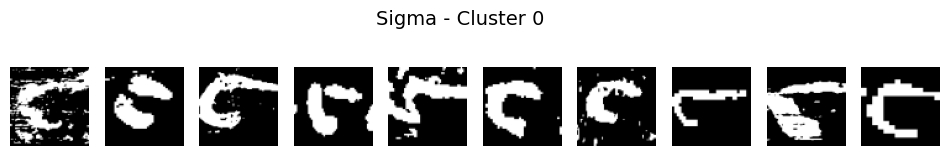

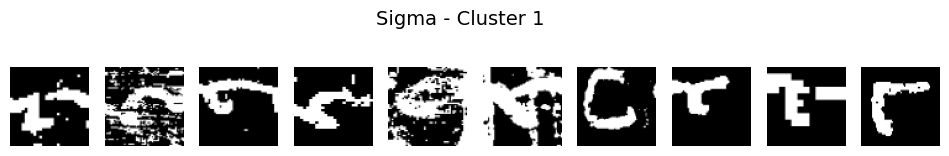

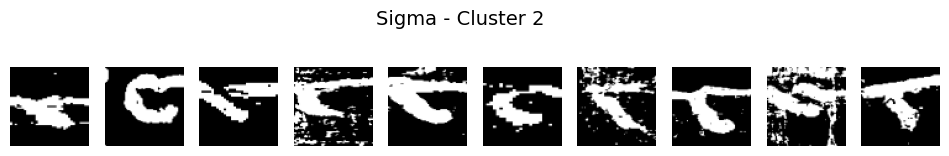

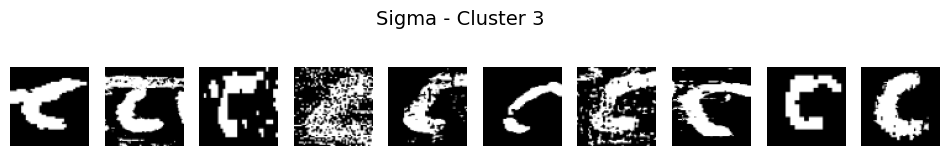

In [37]:
def per_cluster_show(letter = 'Sigma', k=4):
  tau_idx = np.where(label_encoder.classes_ == letter)[0][0]
  tau_indices = np.where(labels == tau_idx)[0]
  tau_embeddings = embeddings[tau_indices]
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  tau_clusters = kmeans.fit_predict(tau_embeddings)

  def show_cluster_images(cluster_id, n=10):
      idxs = tau_indices[tau_clusters == cluster_id]
      if len(idxs) > n:
          idxs = np.random.choice(idxs, n, replace=False)

      plt.figure(figsize=(12, 2))
      for i, idx in enumerate(idxs):
          img, _ = test_loader_2d.dataset[idx]  # (image, label)
          if isinstance(img, torch.Tensor):
              img = img.squeeze().cpu().numpy()

          plt.subplot(1, len(idxs), i+1)
          plt.imshow(img, cmap="gray")
          plt.axis("off")
      plt.suptitle(f"{letter} - Cluster {cluster_id}", fontsize=14)
      plt.show()

  for c in range(k):
      show_cluster_images(c, n=10)

per_cluster_show('Sigma', 4)

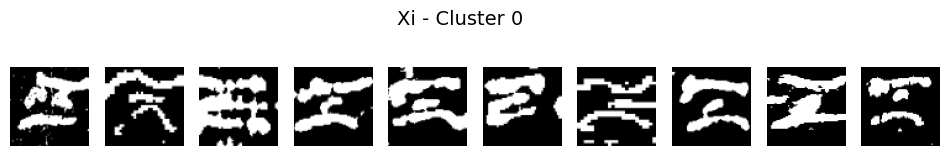

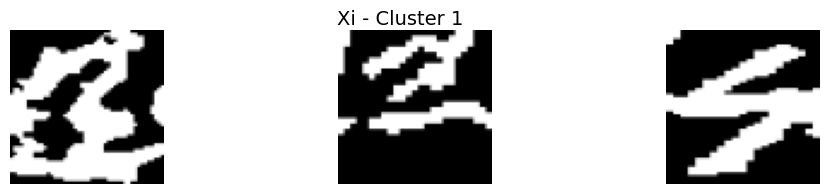

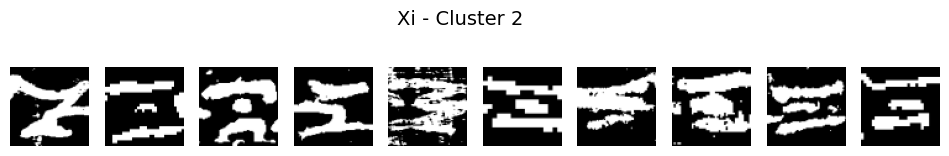

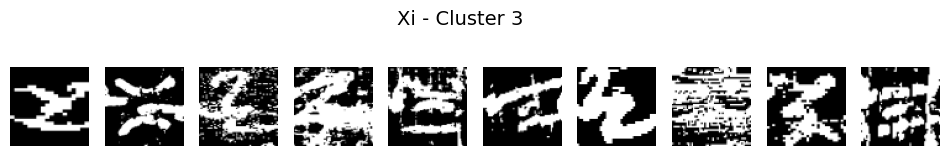

In [38]:
per_cluster_show('Xi', 4)

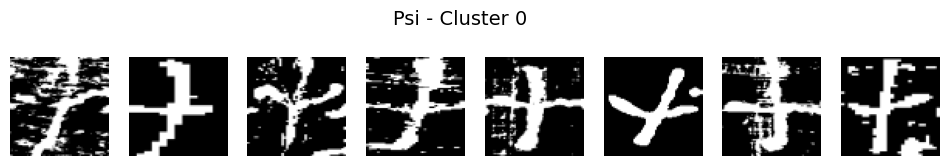

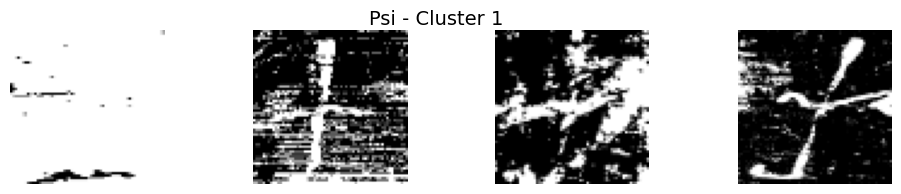

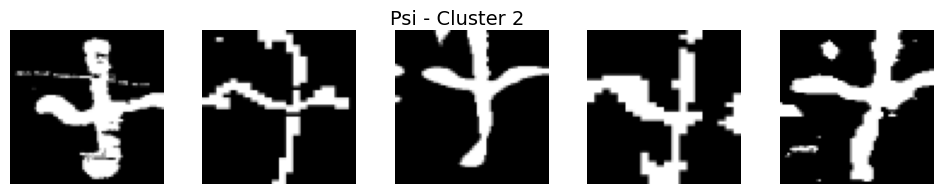

In [39]:
per_cluster_show('Psi', 3)